In [1]:
import pandas as pd

C:\Users\Khyati\AppData\Local\Temp\ipykernel_25436\4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
seed_df = pd.read_csv('channels_trial2/msgs_dataset.csv')

heroesofZ = pd.read_csv('topTen/heroesofZ/msgs_dataset.csv')
lunay14 = pd.read_csv('topTen/Lunay14/Lunay14_green_df.csv')
novosti_efir = pd.read_csv('topTen/novosti_efir/msgs_dataset.csv')
orchestra_w = pd.read_csv('topTen/orchestra_w/orchestra_w_green_df.csv')
rtdru = pd.read_csv('topTen/rtdru/msgs_dataset.csv')
rustroyka1945 = pd.read_csv('topTen/rustroyka1945/rustroyka1945_green_df.csv')
ua_tribunal = pd.read_csv('topTen/ua_tribunal/ua_tribunal_red_df.csv')
voin_dv = pd.read_csv('topTen/voin_dv/voin_dv_green_df.csv')
warfakebelgorod = pd.read_csv('topTen/warfakebelgorod/warfakebelgorod_green_df.csv')
zarussia_1 = pd.read_csv('topTen/zarussia_1/zarussia_1_green_df.csv')

bridge_df = pd.concat([heroesofZ, lunay14,novosti_efir,orchestra_w,rtdru,rustroyka1945,ua_tribunal, voin_dv,warfakebelgorod,zarussia_1], ignore_index=True)

# msg_df = seed_df
msg_df = bridge_df
msg_df.head()

C:\Users\Khyati\AppData\Local\Temp\ipykernel_25436\418229316.py:1: DtypeWarning: Columns (14,16,17,18,19,22,30,33,35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  seed_df = pd.read_csv('channels_trial2/msgs_dataset.csv')
C:\Users\Khyati\AppData\Local\Temp\ipykernel_25436\418229316.py:4: DtypeWarning: Columns (35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  lunay14 = pd.read_csv('topTen/Lunay14/Lunay14_green_df.csv')
C:\Users\Khyati\AppData\Local\Temp\ipykernel_25436\418229316.py:5: DtypeWarning: Columns (35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  novosti_efir = pd.read_csv('topTen/novosti_efir/msgs_dataset.csv')
C:\Users\Khyati\AppData\Local\Temp\ipykernel_25436\418229316.py:12: DtypeWarning: Columns (35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  zarussia_1 = pd.read_csv('topTen/zarussia_1/zarussia_1_green_df.csv')


,signature,channel_id,channel_name,msg_id,message,cleaned_message,date,msg_link,msg_from_peer,msg_from_id,...,contact_name,contact_userid,geo_type,lat,lng,venue_id,venue_type,venue_title,venue_address,venue_provider
0,msg_iteration.0.user.heroesofZ.post.1045,1547226852,heroesofZ,1045,«Удивляешься позитивному отношению пациентов к...,«Удивляешься позитивному отношению пациентов к...,2024-07-14 06:01:36+00:00,https://t.me/heroesofZ/1045,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,msg_iteration.1.user.heroesofZ.post.1044,1547226852,heroesofZ,1044,Майор Сергей Зорин получил тяжелое ранение в з...,Майор Сергей Зорин получил тяжелое ранение в з...,2024-07-13 06:00:38+00:00,https://t.me/heroesofZ/1044,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,msg_iteration.2.user.heroesofZ.post.1043,1547226852,heroesofZ,1043,«Родные поддерживают. Потому что знают: перед ...,«Родные поддерживают. Потому что знают: перед ...,2024-07-12 04:01:57+00:00,https://t.me/heroesofZ/1043,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,msg_iteration.3.user.heroesofZ.post.1042,1547226852,heroesofZ,1042,Старший сержант Сергей Лютков сбил из ПЗРК «Ве...,Старший сержант Сергей Лютков сбил из ПЗРК «Ве...,2024-07-11 04:01:23+00:00,https://t.me/heroesofZ/1042,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,msg_iteration.4.user.heroesofZ.post.1041,1547226852,heroesofZ,1041,"Многим интересно: где сейчас находятся, чем за...","Многим интересно: где сейчас находятся, чем за...",2024-07-10 04:00:50+00:00,https://t.me/heroesofZ/1041,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
!pip install googletrans==3.1.0a0
from googletrans import Translator
translator = Translator(service_urls=[
    'translate.googleapis.com',
  'translate.google.com',
  'translate.google.co.kr',
  'translate.google.co.in',
  'translate.google.co.uk',
])

In [ ]:
def detect_language(message):
    result = translator.detect(message)
    return result.lang

# Apply the function to the cleaned_message column
msg_df['language'] = msg_df['cleaned_message'].apply(detect_language)

# Calculate the percentage of each language
language_counts = msg_df['language'].value_counts(normalize=True) * 100

# Convert to DataFrame for better readability
language_percentage = language_counts.reset_index()

language_percentage.columns = ['language', 'percentage']

# Display the result
print(language_percentage)

In [44]:
msg_df = pd.concat([seed_df, bridge_df], ignore_index=True)

In [45]:
len(bridge_df)

125266

In [46]:
len(seed_df)

898808

In [47]:
# len(seed_df) + len(bridge_df)
len(msg_df)

1024074

In [48]:
msg_df.columns

Index(['signature', 'channel_id', 'channel_name', 'msg_id', 'message',
       'cleaned_message', 'date', 'msg_link', 'msg_from_peer', 'msg_from_id',
       'views', 'number_replies', 'number_forwards', 'is_forward',
       'forward_msg_from_peer_type', 'forward_msg_from_peer_id',
       'forward_msg_from_peer_name', 'forward_msg_date',
       'forward_msg_date_string', 'forward_msg_link', 'is_reply',
       'reply_to_msg_id', 'reply_msg_link', 'contains_media', 'media_type',
       'has_url', 'url', 'domain', 'url_title', 'url_description',
       'document_type', 'document_id', 'document_video_duration',
       'document_filename', 'poll_id', 'poll_question', 'poll_total_voters',
       'poll_results', 'contact_phone_number', 'contact_name',
       'contact_userid', 'geo_type', 'lat', 'lng', 'venue_id', 'venue_type',
       'venue_title', 'venue_address', 'venue_provider', 'just_date'],
      dtype='object')

In [49]:
msg_df['channel_name'].unique()

array(['dva_majors', 'HersonVestnik', 'infodefSPAIN', 'izvestia',
       'kremlinprachka', 'margaritasimonyan',
       'MariaVladimirovnaZakharova', 'pul_1', 'sashakots', 'SolovievLive',
       'ukraina_ru', 'warfakes', 'zvezdanews', 'heroesofZ', 'Lunay14',
       'novosti_efir', 'orchestra_w', 'rtdru', 'rustroyka1945',
       'ua_tribunal', 'voin_dv', 'warfakebelgorod', 'zarussia_1'],
      dtype=object)

In [51]:
# most prominent domains shared

most_prominent_domain = msg_df['domain'].value_counts()
print("The prominent domains are:", most_prominent_domain[most_prominent_domain>250])

The prominent domains are: domain
t.co              36616
t.me              28088
ukraina.ru         9018
telegra.ph         4669
goo.gl             4546
youtu.be           3475
youtube.com        3177
clc.to             1809
rutube.ru          1050
izvestia.ru         998
is.gd               990
vk.com              796
kp.ru               701
russian.rt.com      530
m.kp.ru             337
ria.ru              327
tvzvezda.ru         255
instagram.com       255
twitter.com         251
Name: count, dtype: int64


In [54]:
# most prominent url_descriptions shared

most_prominent_url_description = msg_df['url_description'].value_counts()
print("The most prominent url_description are:", most_prominent_url_description[most_prominent_url_description>100])
# print("The most prominent url_description is:", most_prominent_url_description)

The most prominent url_description are: url_description
Владимир Соловьев в Telegram.\nКонтакт: solovievlive@protonmail.com                                                                                                                                                                                                          1891
Проект для тех кто хочет изучить военное дело и грамотно применять полученные знания.\n\nЕсли у вас есть полезная информация или интересные материалы и фото которые мы можем выложить на ПРАВАХ АНОНИМНОСТИ.\n@InformatorGRU_bot\n\nМенеджер канала: @svyazRus               162
InfoDefense es un grupo de voluntarios de todas las partes del mundo.\n\nEstamos diciendo la verdad sobre la que la mayoría de los medios prefieren guardar silencio.\n\nMás de 20 canales en diferentes idiomas. \nLa lista: @InfoDefALL\n\n@InfoDefenseMailBot              113
Главный по Украине\n\nОфициальная страница интернет-издания Ukraina.ru в Telegram\n\nПоддержать Украина.ру:https://t.me/uk

In [57]:
# most prominent url_title shared

most_prominent_url_title = msg_df['url_title'].value_counts()
print("The prominent url_title are:", most_prominent_url_title[most_prominent_url_title>140])
# print("The prominent url_title is:", most_prominent_url_title)

The prominent url_title are: url_title
СОЛОВЬЁВ                     2395
Kotsnews                     1245
RT на русском                1152
Два майора                    766
Украина.ру                    697
Zvezdanews                    565
РИА Новости                   456
Sputnik Ближнее зарубежье     453
Пул N3                        406
Маргарита Симоньян            358
Рыбарь                        341
Раньше всех. Ну почти.        286
Наука побеждать               278
Херсонский Вестник            244
Кремлёвская прачка            210
ТРОЙКА 🏴‍☠️                   208
Андрей Медведев               203
Зрада чи Перемога             200
Юлия Витязева                 167
СОЛОВЬЕВ                      164
Донбасс решает                159
Name: count, dtype: int64


In [58]:
# top posts with maximum views

# Set display options
pd.set_option('display.max_colwidth', None)

top_posts = (msg_df.sort_values(by='views', ascending=False)).head(10)
top_posts_df = pd.DataFrame(top_posts)
# print(list(top_posts_df['cleaned_message']))
# top_posts_df['cleaned_message']
top_posts_df
# print(top_posts['cleaned_message'].to_string(index=False))

,signature,channel_id,channel_name,msg_id,message,cleaned_message,date,msg_link,msg_from_peer,msg_from_id,...,contact_userid,geo_type,lat,lng,venue_id,venue_type,venue_title,venue_address,venue_provider,just_date
468177,msg_iteration.141343.user.SolovievLive.post.95814,1315735637,SolovievLive,95814,📺Подписывайтесь и смотрите прямой эфир телеканала СоловьёвLive на удобной для себя платформе:\n\nRutube\n\nVK \n\nОдноклассники\n \nСмотрим\n\nRutube (24 часа)\n\n🗣Или слушайте на СоловьёвFM\n\n🎥А также смотрите истории!,📺Подписывайтесь и смотрите прямой эфир телеканала СоловьёвLive на удобной для себя платформе: Rutube VK Одноклассники Смотрим Rutube (24 часа) 🗣Или слушайте на СоловьёвFM 🎥А также смотрите истории!,2022-03-23 04:47:55+00:00,https://t.me/SolovievLive/95814,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
468178,msg_iteration.141344.user.SolovievLive.post.95813,1315735637,SolovievLive,95813,"Украина выводит свои самолеты и БЛА Bayraktar TB2 из аэропорта Ужгорода, который находится впритык к словацкой границе и долгое время не был атакован. Видимо, что-то поменялось или поменяется","Украина выводит свои самолеты и БЛА Bayraktar TB2 из аэропорта Ужгорода, который находится впритык к словацкой границе и долгое время не был атакован. Видимо, что-то поменялось или поменяется",2022-03-23 04:43:08+00:00,https://t.me/SolovievLive/95813,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
468176,msg_iteration.141342.user.SolovievLive.post.95815,1315735637,SolovievLive,95815,"Правовая система США продолжает деградировать.\nОт официальных лиц Вашингтона практически одновременно прозвучали два противоречащих друг другу заявления. \n\nСначала пресс-секретарь Белого дома Джен Псаки сказала, что Штаты не просили американские компании уходить с российского рынка. Затем буквально через несколько часов Конгресс предложил запретить правительству США вести дела с компаниями, которые несмотря на санкции продолжили работу в России.\n\nНедавно уже говорил о двойных стандартах Вашингтона: Конгресс США запретил любую помощь батальону «Азов» (организация признана экстремистской и запрещена в РФ), но Байден вопреки закону финансирует этих неонацистов, направляет им оружие. \n\nЗадумайтесь, чего можно ожидать от США, которые обладают ядерным оружием и многое определяют в мире, если закон для их руководства не писан, а политические заявления ничего не стоят.\n\nКто-то посмеется, что разговор о «загнивающем Западе» в нашей стране ведется давно. Но сегодня хаос в США точно наступил.","Правовая система США продолжает деградировать. От официальных лиц Вашингтона практически одновременно прозвучали два противоречащих друг другу заявления. Сначала пресс-секретарь Белого дома Джен Псаки сказала, что Штаты не просили американские компании уходить с российского рынка. Затем буквально через несколько часов Конгресс предложил запретить правительству США вести дела с компаниями, которые несмотря на санкции продолжили работу в России. Недавно уже говорил о двойных стандартах Вашингтона: Конгресс США запретил любую помощь батальону «Азов» (организация признана экстремистской и запрещена в РФ), но Байден вопреки закону финансирует этих неонацистов, направляет им оружие. Задумайтесь, чего можно ожидать от США, которые обладают ядерным оружием и многое определяют в мире, если закон для их руководства не писан, а политические заявления ничего не стоят. Кто-то посмеется, что разговор о «загнивающем Западе» в нашей стране ведется давно. Но сегодня хаос в США точно наступил.",2022-03-23 04:59:56+00:00,https://t.me/SolovievLive/95815,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
289756,msg_iteration.4010.user.sashakots.post.41117,1109403194,sashakots,41117,"⚡️⚡️⚡️Русскому Старлинку быть!\n\nЗапущенные с космодрома «Восточный» три отечественных низкоорбитальных спутника связи, которые разработала российская компания «Бюро 1440», дали первый интернет.\n\nСейчас скорость передачи данных на устройство составляет 12 Мбит/сек, а задержка — 41 миллисекунда. Следующий

In [59]:
top_posts_df['channel_name'].unique()

array(['SolovievLive', 'sashakots', 'rustroyka1945'], dtype=object)

In [60]:
# no of total, forwards and OG posts
# Count total messages
total_messages = len(msg_df)

# Count forwarded messages
forwarded_messages = len(msg_df[msg_df['is_forward']==1])

# Count original posts
original_posts = total_messages - forwarded_messages

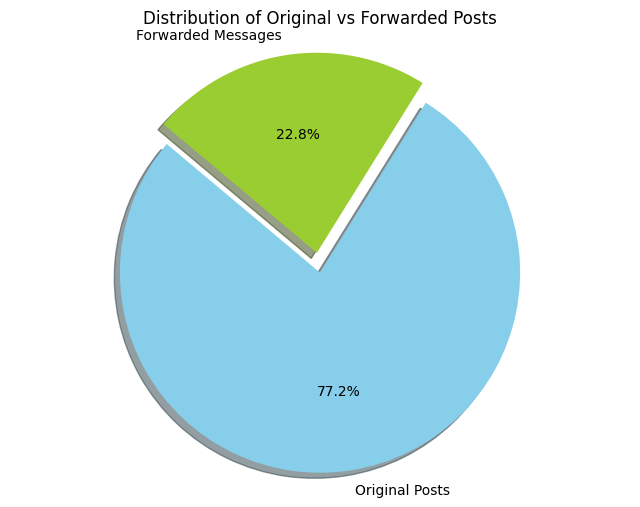

In [61]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Original Posts', 'Forwarded Messages']
sizes = [original_posts, forwarded_messages]
colors = ['skyblue', 'yellowgreen']
explode = (0.1, 0)  # explode 1st slice (Original Posts)

# Plot
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Original vs Forwarded Posts')
plt.show()

2015-09-24 - 2024-07-14


<Axes: xlabel='Date'>

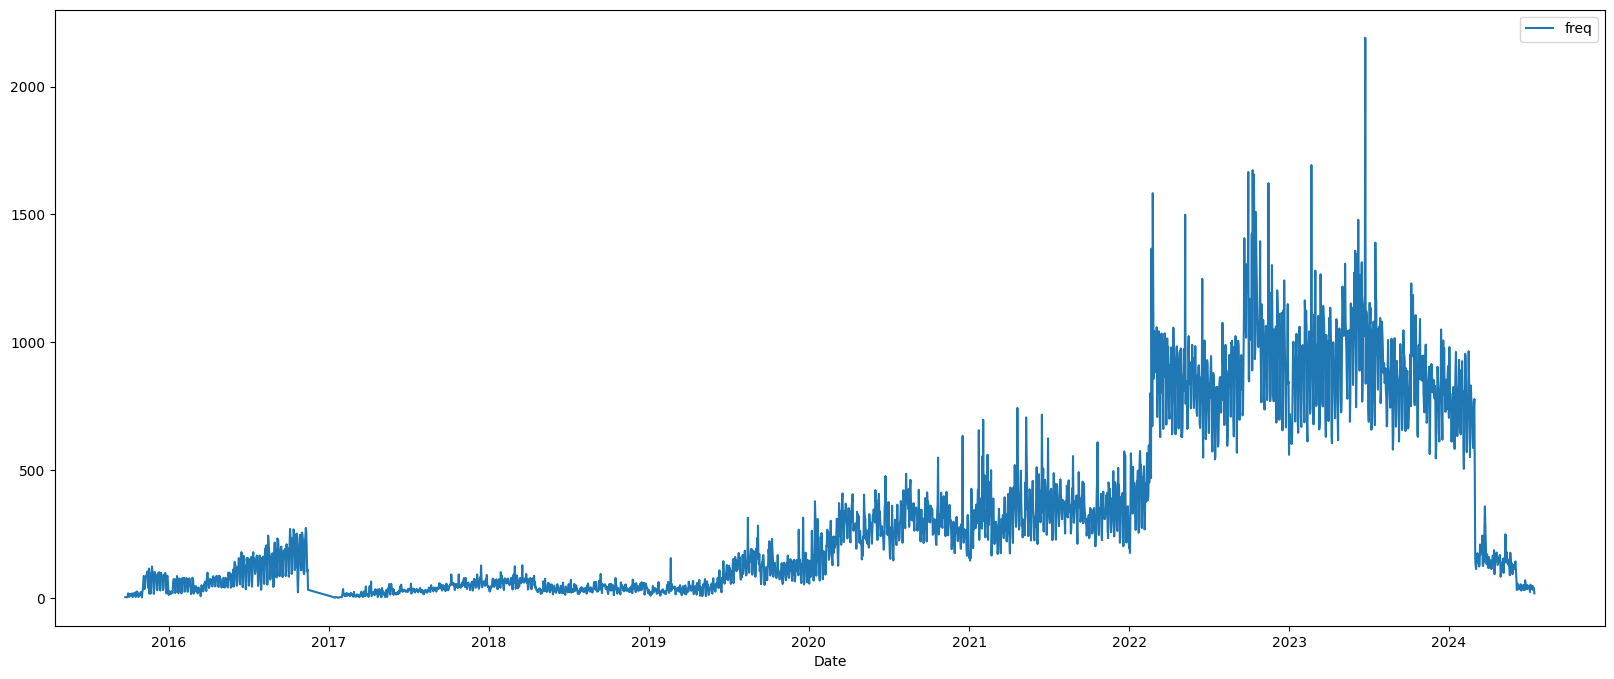

In [62]:
msg_df["just_date"] = pd.to_datetime(msg_df.date).dt.date
# date range
print(f"{msg_df.just_date.min()} - {msg_df.just_date.max()}")

# Daily frequency of messages
daily_count_merged = msg_df.groupby("just_date").size().reset_index(name="freq")
daily_count_merged.plot(x="just_date", y="freq", xlabel="Date", figsize= (20, 8))

In [63]:
daily_count_merged_sorted = daily_count_merged.sort_values(by="freq", ascending=False)
daily_count_merged_sorted.head(20)

,just_date,freq
2766,2023-06-24,2191
2643,2023-02-21,1693
2509,2022-10-10,1673
2499,2022-09-30,1666
2512,2022-10-13,1656
2545,2022-11-15,1622
2281,2022-02-24,1583
2516,2022-10-17,1510
2355,2022-05-09,1499
2750,2023-06-08,1479


In [64]:
daily_count_merged_sorted_20 = daily_count_merged_sorted.head(20)

In [65]:
# %%capture
# !pip install seaborn
import seaborn as sns

In [ ]:
posts_in_dates = msg_df[msg_df['just_date'].isin((daily_count_merged_sorted['just_date']))]

# Group by 'channel_name' and 'date' and count the number of posts in each channel on each date
channel_post_counts = posts_in_dates.groupby(['just_date', 'channel_name']).size().unstack(fill_value=0)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(channel_post_counts, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Channels')
plt.ylabel('Dates')
plt.title('Number of Posts Shared by Channels')
plt.show()

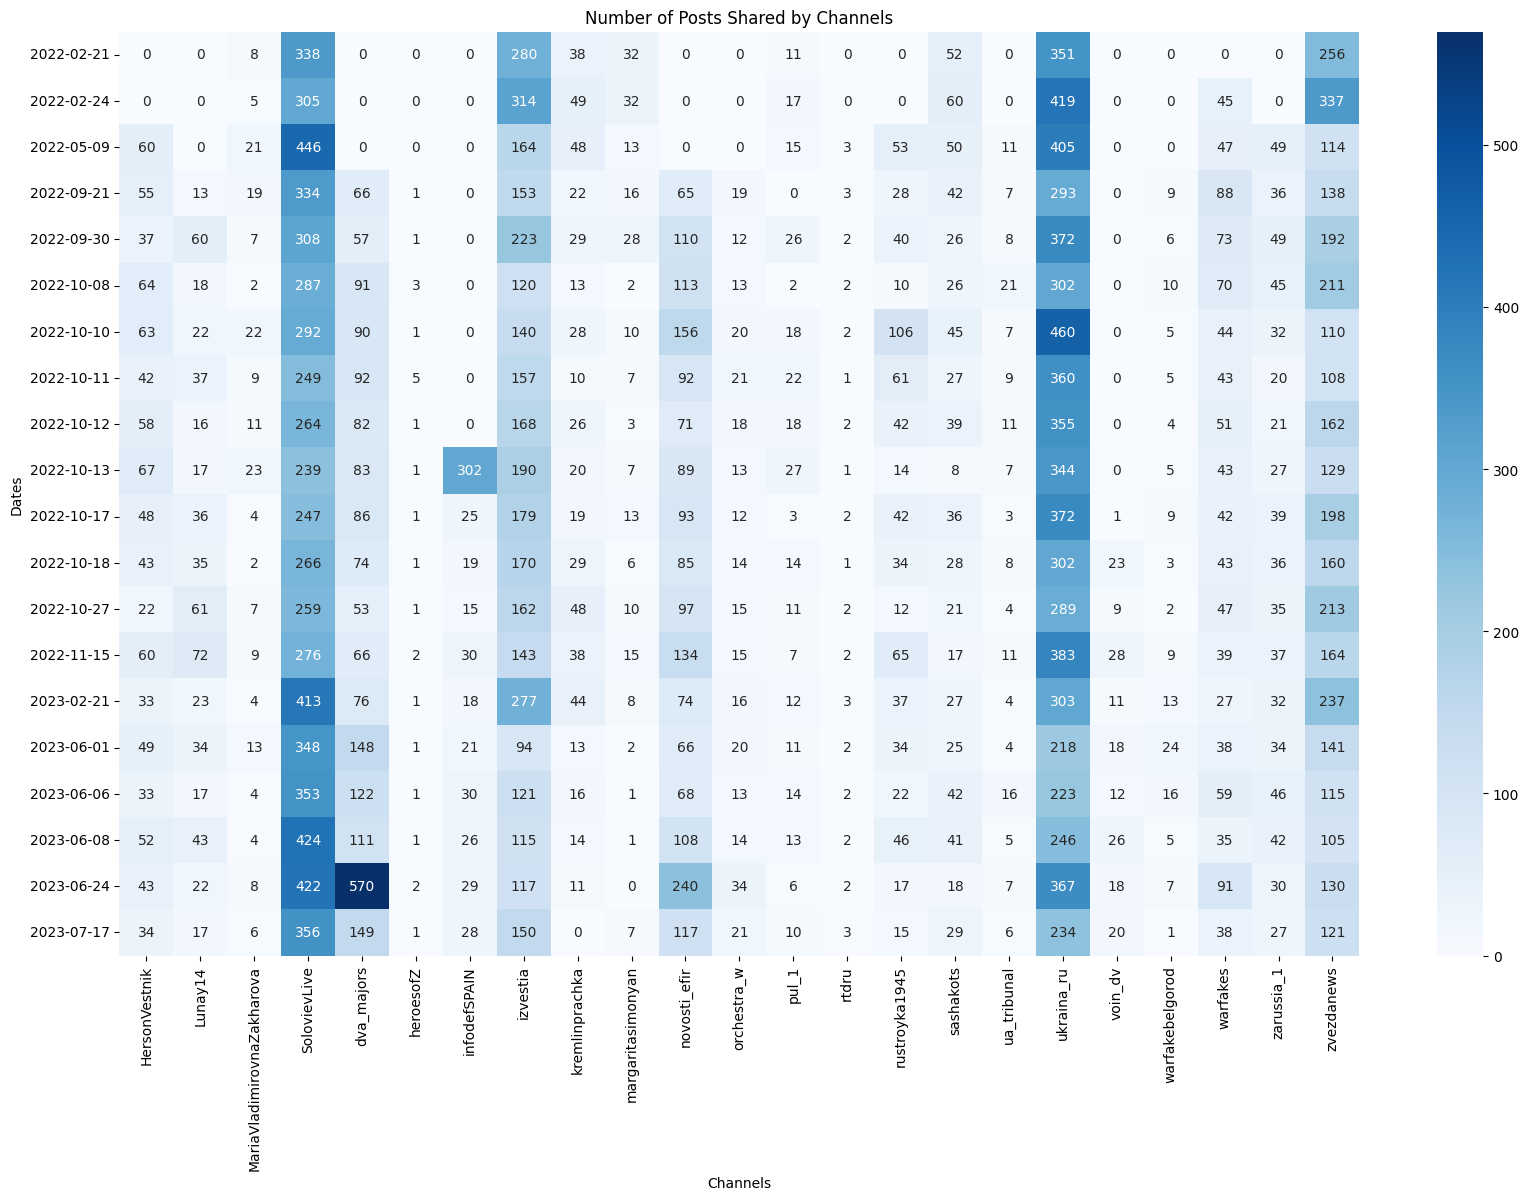

In [68]:
posts_in_dates = msg_df[msg_df['just_date'].isin((daily_count_merged_sorted_20['just_date']))]

# Group by 'channel_name' and 'date' and count the number of posts in each channel on each date
channel_post_counts = posts_in_dates.groupby(['just_date', 'channel_name']).size().unstack(fill_value=0)

# Create the heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(channel_post_counts, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Channels')
plt.ylabel('Dates')
plt.title('Number of Posts Shared by Channels')
plt.show()

In [69]:
d = "2023-06-24"	
# Convert 'date' column to datetime type
msg_df['date'] = pd.to_datetime(msg_df['date'])

# Filter the DataFrame to include only posts from '2023-02-08'
posts_2023_02_08 = msg_df[msg_df['date'].dt.date == pd.to_datetime(d).date()]

# Group by 'channel_name' and count the number of posts in each channel
channel_post_counts = posts_2023_02_08['channel_name'].value_counts()

# Print the names of the channels along with the number of posts in each
print(f"Channels that shared posts on {d}:")
for channel, count in channel_post_counts.items():
    print(f"{channel}: {count} posts")


Channels that shared posts on 2023-06-24:
dva_majors: 570 posts
SolovievLive: 422 posts
ukraina_ru: 367 posts
novosti_efir: 240 posts
zvezdanews: 130 posts
izvestia: 117 posts
warfakes: 91 posts
HersonVestnik: 43 posts
orchestra_w: 34 posts
zarussia_1: 30 posts
infodefSPAIN: 29 posts
Lunay14: 22 posts
sashakots: 18 posts
voin_dv: 18 posts
rustroyka1945: 17 posts
kremlinprachka: 11 posts
MariaVladimirovnaZakharova: 8 posts
ua_tribunal: 7 posts
warfakebelgorod: 7 posts
pul_1: 6 posts
heroesofZ: 2 posts
rtdru: 2 posts


In [70]:
channel_post_counts

channel_name
dva_majors                    570
SolovievLive                  422
ukraina_ru                    367
novosti_efir                  240
zvezdanews                    130
izvestia                      117
warfakes                       91
HersonVestnik                  43
orchestra_w                    34
zarussia_1                     30
infodefSPAIN                   29
Lunay14                        22
sashakots                      18
voin_dv                        18
rustroyka1945                  17
kremlinprachka                 11
MariaVladimirovnaZakharova      8
ua_tribunal                     7
warfakebelgorod                 7
pul_1                           6
heroesofZ                       2
rtdru                           2
Name: count, dtype: int64

In [71]:
# Convert 'date' column to datetime type
msg_df['date'] = pd.to_datetime(msg_df['date'])

# Filter the DataFrame to include only posts from '2023-02-08'
posts_2023_02_08 = msg_df[msg_df['date'].dt.date == pd.to_datetime('2023-02-08').date()]

# Group by 'channel_name' and count the number of posts in each channel
channel_post_counts = posts_2023_02_08['channel_name'].value_counts()

# Print the names of the channels along with the number of posts in each
print("Channels that shared posts on 2023-02-08:")
for channel, count in channel_post_counts.items():
    print(f"{channel}: {count} posts")


Channels that shared posts on 2023-02-08:
SolovievLive: 251 posts
ukraina_ru: 184 posts
zvezdanews: 162 posts
izvestia: 130 posts
novosti_efir: 50 posts
dva_majors: 37 posts
zarussia_1: 27 posts
HersonVestnik: 26 posts
rustroyka1945: 22 posts
kremlinprachka: 18 posts
warfakes: 18 posts
sashakots: 15 posts
orchestra_w: 15 posts
infodefSPAIN: 12 posts
voin_dv: 12 posts
MariaVladimirovnaZakharova: 11 posts
warfakebelgorod: 8 posts
Lunay14: 7 posts
ua_tribunal: 6 posts
rtdru: 4 posts
pul_1: 3 posts
margaritasimonyan: 3 posts
heroesofZ: 1 posts


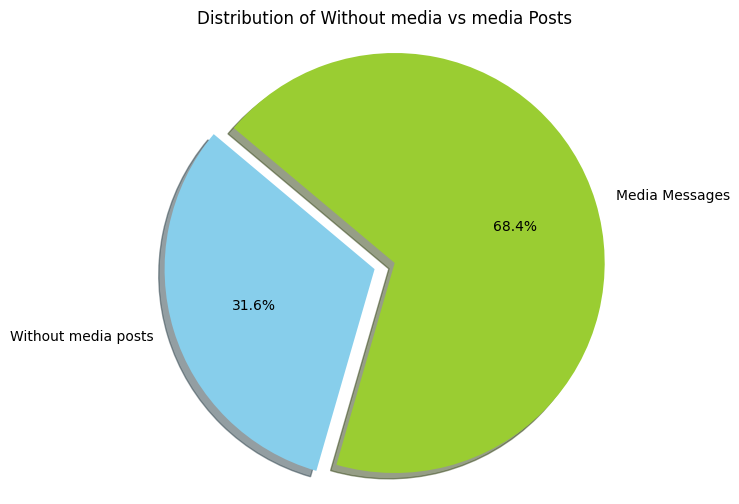

In [72]:
# no of posts containing media
# Count total messages
total_messages = len(msg_df)

# Count forwarded messages
media_messages = len(msg_df[msg_df['contains_media']==1])

# Count original posts
without_media_msgs = total_messages - media_messages

# Data to plot
labels = ['Without media posts', 'Media Messages']
sizes = [without_media_msgs, media_messages]
colors = ['skyblue', 'yellowgreen']
explode = (0.1, 0)  # explode 1st slice (Original Posts)

# Plot
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Without media vs media Posts')
plt.show()

<Axes: xlabel='Media Type', ylabel='Prop of messages'>

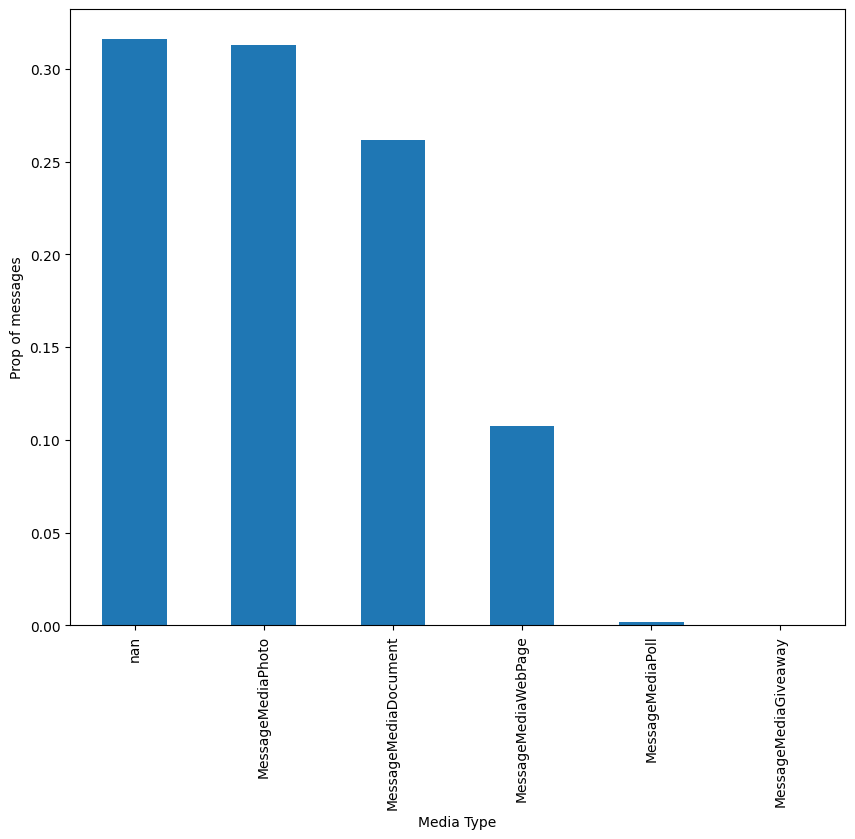

In [73]:
# prominent type of medias
msg_df["media_type"].value_counts(normalize=True, dropna=False).plot(
    kind="bar",
    ylabel="Prop of messages",
    xlabel = "Media Type",
    figsize=(10,8))

In [74]:
# most prominent "forward_msg_from_peer_name"
# Filter out rows where the message is forwarded
forwarded_messages_df = msg_df[msg_df['is_forward']==1]

# Group by 'forward_msg_from_peer_name' and count occurrences
forwarded_msg_counts = forwarded_messages_df['forward_msg_from_peer_name'].value_counts()

# Get the top 20 most prominent names
forwarded_msg_counts.head(25)

forward_msg_from_peer_name
kremlinprachka                7803
rt_russian                    6367
rian_ru                       5652
youlistenedmayak              5250
dimsmirnov175                 4213
rentv_news                    3941
truekpru                      3684
warfakes                      3519
boris_rozhin                  2896
vityzeva                      2790
sashakots                     2720
imerkouri                     2461
bbbreaking                    2160
RVvoenkor                     2110
epoddubny                     2023
romagolovanov                 1898
kornilov1968                  1898
rybar                         1880
savanichi                     1880
SergeyKolyasnikov             1841
ukraina_ru                    1781
sputniklive                   1756
MariaVladimirovnaZakharova    1520
ASGasparyan                   1492
quarantinelive                1442
Name: count, dtype: int64

In [28]:
msg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125266 entries, 0 to 125265
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   signature                   125266 non-null  object             
 1   channel_id                  125266 non-null  int64              
 2   channel_name                125266 non-null  object             
 3   msg_id                      125266 non-null  int64              
 4   message                     93269 non-null   object             
 5   cleaned_message             93269 non-null   object             
 6   date                        125266 non-null  datetime64[ns, UTC]
 7   msg_link                    125266 non-null  object             
 8   msg_from_peer               0 non-null       float64            
 9   msg_from_id                 0 non-null       float64            
 10  views                       125266 non-null 

In [76]:
len(msg_df)

1024074

In [75]:
msg_df['number_forwards'].mean()

232.5759310362337

In [77]:
msg_df['number_replies'].mean()

3.0731294808773586

In [78]:
msg_df['views'].mean()

111506.46286303528

In [81]:
df_sorted = msg_df.sort_values(by='number_forwards', ascending=False)
df_sorted[['views','msg_link','just_date','media_type','number_forwards','is_forward']].head(30)

,views,msg_link,just_date,media_type,number_forwards,is_forward
922007,2547291,https://t.me/novosti_efir/50871,2024-03-23,MessageMediaDocument,129408,0
922218,2137512,https://t.me/novosti_efir/50640,2024-03-22,MessageMediaDocument,96928,0
299124,3931081,https://t.me/sashakots/31294,2022-04-15,MessageMediaDocument,86476,0
968801,3424344,https://t.me/rtdru/827,2022-11-11,MessageMediaDocument,61243,0
276516,2918659,https://t.me/pul_1/9275,2023-06-24,NaN,57904,0
921886,2058128,https://t.me/novosti_efir/50997,2024-03-24,MessageMediaPhoto,55710,0
921885,2043892,https://t.me/novosti_efir/50998,2024-03-24,MessageMediaPhoto,55375,0
921873,1939373,https://t.me/novosti_efir/51010,2024-03-24,MessageMediaPhoto,54680,0
921872,1942752,https://t.me/novosti_efir/51011,2024-03-24,MessageMediaPhoto,54451,0
921876,1921152,https://t.me/novosti_efir/51007,2024-03-24,MessageMediaPhoto,54274,0


In [82]:
df_sorted = msg_df.sort_values(by='number_replies', ascending=False)
df_sorted[['views','msg_link','just_date','media_type','number_replies','number_forwards','is_forward']].head(30)

,views,msg_link,just_date,media_type,number_replies,number_forwards,is_forward
271822,828300,https://t.me/MariaVladimirovnaZakharova/2915,2022-06-15,MessageMediaPhoto,4146,5886,0
473063,288663,https://t.me/SolovievLive/90530,2022-03-02,MessageMediaPhoto,3938,1021,0
271691,705417,https://t.me/MariaVladimirovnaZakharova/3052,2022-07-02,MessageMediaDocument,3936,7154,0
271581,1048761,https://t.me/MariaVladimirovnaZakharova/3170,2022-07-16,MessageMediaPhoto,3494,25784,0
4187,1153709,https://t.me/dva_majors/31251,2023-12-21,MessageMediaPhoto,3032,38162,0
269513,223220,https://t.me/MariaVladimirovnaZakharova/5449,2023-05-17,MessageMediaDocument,2943,713,0
270954,1040531,https://t.me/MariaVladimirovnaZakharova/3881,2022-10-08,NaN,2835,1162,0
270473,201647,https://t.me/MariaVladimirovnaZakharova/4411,2022-12-23,MessageMediaPhoto,2820,315,0
270373,306445,https://t.me/MariaVladimirovnaZakharova/4515,2022-12-31,MessageMediaPhoto,2715,306,0
472190,224787,https://t.me/SolovievLive/91475,2022-03-06,MessageMediaDocument,2483,1982,1
